In [2]:
# Week 1: Data Preparation & Basic Regression  
# Project 1: Real Estate Valuation – House Price Prediction

#TASK 1: 

In [3]:
#installed the necessary libraries.

!pip install pandas numpy matplotlib seaborn scikit-learn


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#pandas for the Tables
#numpy to perform mathematical operations
#matplot/seaborn for Graphs (represenations)
#Scikit-learn used here to load the dataset

In [5]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)

#Used the sklearn and then using openml download the BOSTON dataset

#BOSTON DATASET : has 506 rows (containg houses) details like (Age : how old house is) etc. Total there are 13 features and 1 target variable.

c:\users\mub\appdata\local\programs\python\python38\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [6]:
#Here we are separating the feature and the target variable.

# X are the features(input variables)
X = boston.data

# Y is the target variable(what we are predicting)
y = boston.target

# created a new copied dataframe to see the both features and the target in a single table.
df = X.copy()

#MEDV is the target Variable, what we are predicting(Median value of homes)
df["MEDV"] = y 

#displaying the table to see all things are corectly there
df.head()

#shows all variables are numerical, making the dataset suitable for regression analysis.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
#seeing the size of my dataset.
#506 rows and 14 columns (13 features and 1 target)

df.shape


(506, 14)

In [9]:
df.dtypes

#shows all the datatype of the columns in my dataset, important as the regression model can be only used on numbers not string or text.


CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object

In [10]:
df.describe()

#The describe() function tells the mean, minimum, maximum, and standard deviation for each feature.

#tells that if there is any extreme value (outlier) or the avg house price and many more.

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


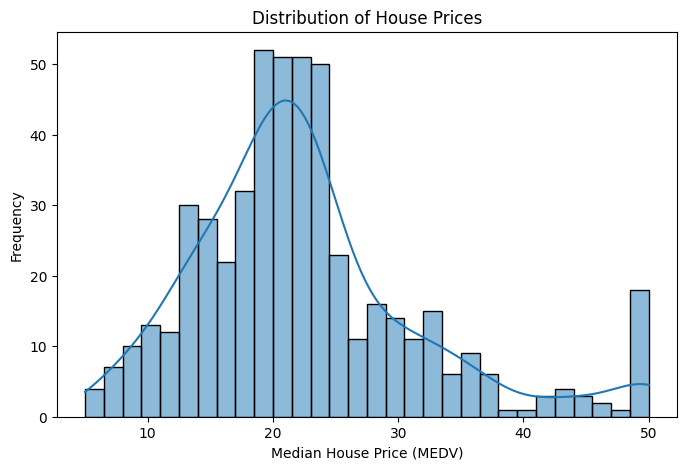

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=30, kde=True)
plt.xlabel("Median House Price (MEDV)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

#checking the spread of house prices. Are they skewed(left or right)


#The distribution a slight right-skewed pattern, showing that mostly the houses have a moderate price but some are expensive as well.

In [ ]:
# Summary of Dataset Characteristics

# The Boston Housing dataset contains 506 observations of houses like Crimerate, age of house etc, and 14 variables.
# There are 13 input features and one target variable (MEDV).
# All features are numerical, making the dataset suitable for regression analysis.
# Target variable represents the median house price in thousands of dollars.
# Most house prices fall in the mid-range, with a small number of higher-priced houses.




In [14]:
#TASK 2: Missing Value Analysis


#WHY MISSING VALUES OCCUR:
    #They can occur if the data was not recorded or there is any sensor failure or if like the data have been collected manually so the human may cause error.

#RISK: 
    #The predictions can be biased or the training of model can become incorrect, model may become overfit or underfit


In [15]:
#CHECK FOR MISSING VALUES:

df.isnull().sum()

#add all the null columns.

#shows no missing value, dataset has no missing value.

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [24]:
#Missing values were added to show handling techniques. The original dataset contains no missing values.

In [16]:
#Strategies for missing values: 

#ADD Missing values to see the strategies: 

df_missing = df.copy()

df_missing.loc[0:5, "RM"] = np.nan
df_missing.loc[10:15, "TAX"] = np.nan

#Strategy 1: MEAN/MEDIUM:

df_imputed = df_missing.copy()

df_imputed["RM"].fillna(df_imputed["RM"].mean(), inplace=True)
df_imputed["TAX"].fillna(df_imputed["TAX"].median(), inplace=True)

#Mean imputation was applied to the RM feature and median imputation was applied to TAX. 

#Strategy 2: Row Removal:

df_dropped = df_missing.dropna()

#Rows containing missing values were removed, only use when number of missing values is small.


In [17]:
#COMPARISON:

print("Before Handling Missing Values:")
print(df_missing.isnull().sum())

print("\nAfter Mean/Median Imputation:")
print(df_imputed.isnull().sum())

print("\nAfter Row Removal:")
print(df_dropped.isnull().sum())

#BEFORE:

#Tax and RM had 6 missing values later they were removed.


Before Handling Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         6
AGE        0
DIS        0
RAD        0
TAX        6
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

After Mean/Median Imputation:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

After Row Removal:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [33]:
## Missing Value Handling Justification

#Mean and median were used because they preserve the dataset size and are effective when missing values are minimal. 
#Row removal is also done but is only use when missing data is limited, as it reduces the number of rows.

In [18]:
#TASK 3: Outlier Detection & Treatment

#Detect OUTLIERS: USING IQR (Q3 - Q1)

Q1 = df["MEDV"].quantile(0.25)
Q3 = df["MEDV"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["MEDV"] < lower_bound) | (df["MEDV"] > upper_bound)]
outliers_iqr.shape

#The IQR method was used to identify outliers in the target variable MEDV. Values outside the acceptable range were classified as outliers.



(40, 14)

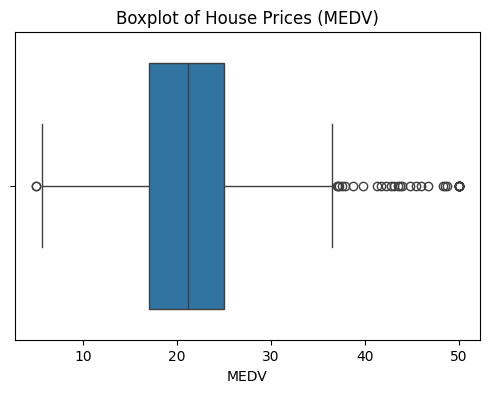

In [19]:
#BOX PLOT:

plt.figure(figsize=(6,4))
sns.boxplot(x=df["MEDV"])
plt.title("Boxplot of House Prices (MEDV)")
plt.show()


#The boxplot shows the presence of outliers in the upper range of house prices.



In [20]:
#USE Z-Score:

#RULE = z > 3 = outlier

from scipy.stats import zscore

z_scores = zscore(df["MEDV"])
outliers_z = df[abs(z_scores) > 3]
outliers_z.shape


#Z-score analysis was used to detect extreme values. Data points with a Z-score greater than 3 were considered outliers.
#0 rows were detected as outlier (No outlier here in z score)

(0, 14)

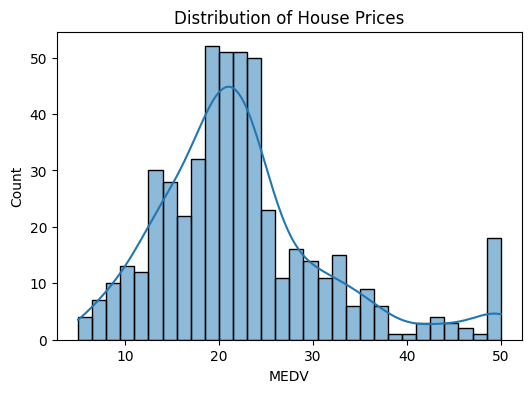

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df["MEDV"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

#Right skewed distribution similar as above.


In [22]:
#Method to Remove outliers: 

#We are applying Clapping(JUSTIFICATION):

#Clapping: 
    #It keeps all data and limits extreme values which is great for regression.

df_capped = df.copy()

df_capped["MEDV"] = np.where(
    df_capped["MEDV"] > upper_bound,
    upper_bound,
    df_capped["MEDV"]
)

#Outliers were treated using capping, where extreme values were limited to the upper bound.



In [23]:
#CLEANED DATASET:
df_cleaned = df_capped.copy()
df_cleaned.head()

#FINAL: The capped dataset was selected as cleaned dataset because it reduces the impact of outliers without removing rows like others.



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


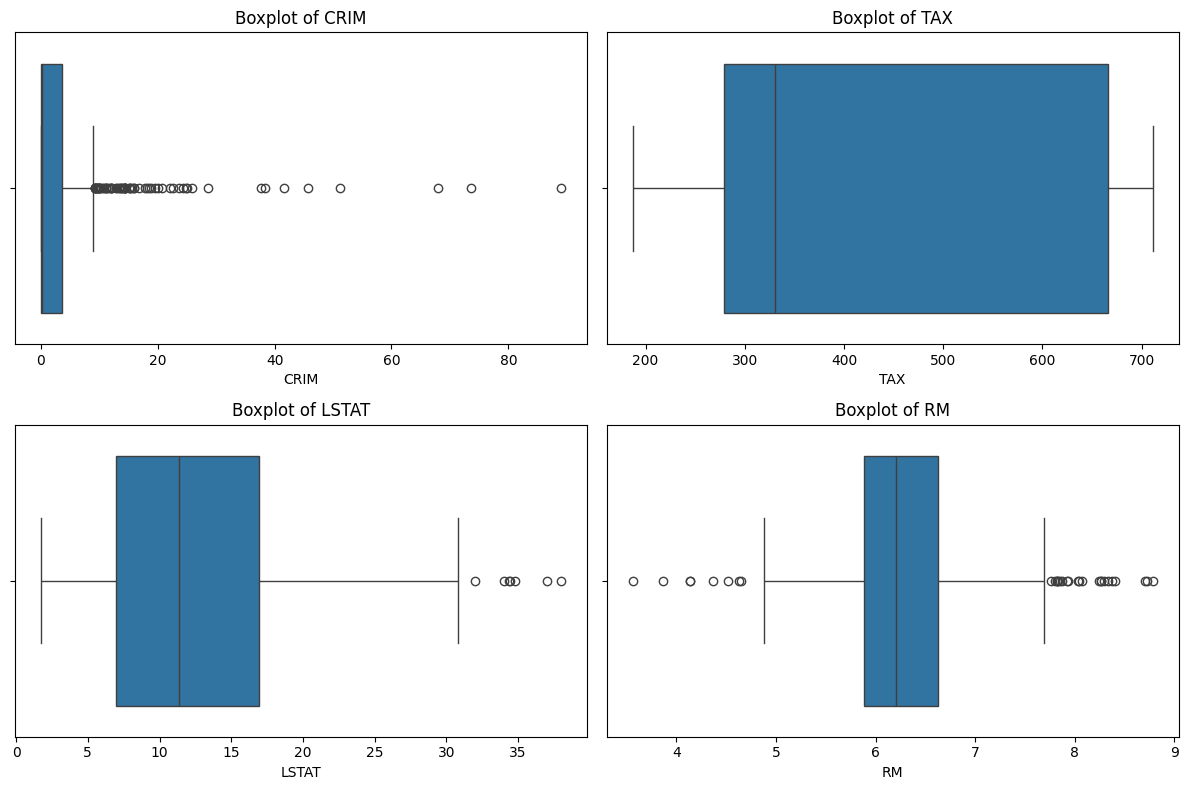

In [27]:
#check the boxplot for the outliers for the important features like [CRIM, Tax etc]

features_to_check = ["CRIM", "TAX", "LSTAT", "RM"]

plt.figure(figsize=(12,8))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


In [29]:
df_feature_capped = df_cleaned.copy()

for col in ["CRIM", "TAX", "LSTAT"]:
    Q1 = df_feature_capped[col].quantile(0.25)
    Q3 = df_feature_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    df_feature_capped[col] = np.where(
        df_feature_capped[col] > upper_bound,
        upper_bound,
        df_feature_capped[col]
    )

In [30]:
df_feature_capped.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [31]:
#SUMMARY AND JUSTIFICATION:

# Outliers were detected using both IQR and Z-score methods.
# Boxplots and distribution plots were used for visualization.
# Outliers were treated using capping.
# Capping was applied to the target variable and selected skewed features. 
# features with stable and meaningful distributions, such as RM, were left unchanged. 
# Capping was chosen as the method to preserve data while reducing outlier.
# The cleaned dataset is now ready for regression modeling.


In [32]:
X = df_feature_capped.drop("MEDV", axis=1)
y = df_feature_capped["MEDV"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [39]:
X_train["CHAS"] = X_train["CHAS"].astype(int)
X_test["CHAS"] = X_test["CHAS"].astype(int)

X_train["RAD"] = X_train["RAD"].astype(int)
X_test["RAD"] = X_test["RAD"].astype(int)

In [40]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_model.intercept_

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,CRIM,-0.503420
1,ZN,0.031927
2,INDUS,-0.003087
3,CHAS,1.322545
4,NOX,-12.395920
5,RM,2.916456
6,AGE,-0.012389
7,DIS,-1.178767
8,RAD,0.313512
9,TAX,-0.010158


In [43]:
y_pred = lr_model.predict(X_test)
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

,Actual,Predicted
0,23.6,27.737821
1,32.4,32.973482
2,13.6,14.555869
3,22.8,24.937748
4,16.1,18.169453
5,20.0,22.502476
6,17.8,18.087907
7,14.0,14.365679
8,19.6,22.012544
9,16.8,20.805081


In [48]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

evaluation_results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R²"],
    "Value": [mse, rmse, r2]
})

evaluation_results

,Metric,Value
0,MSE,12.135836
1,RMSE,3.483653
2,R²,0.752049


In [ ]:
#justification:

#The model predicts strong performance with R² value of approximately 0.75.

#This indicates that 75% of the variation in house prices is explained by the model.

#The RMSE value of about 3.5 suggests that the model’s predictions are reasonably accurate.

#The evaluation results indicate that the model is neither underfitting nor overfitting and generalizes well to unseen data 

# As R = 0.1 (low ) = underfit
# overfit = R on train high while R on test is low but here R is 0.75 so it generalizes well.

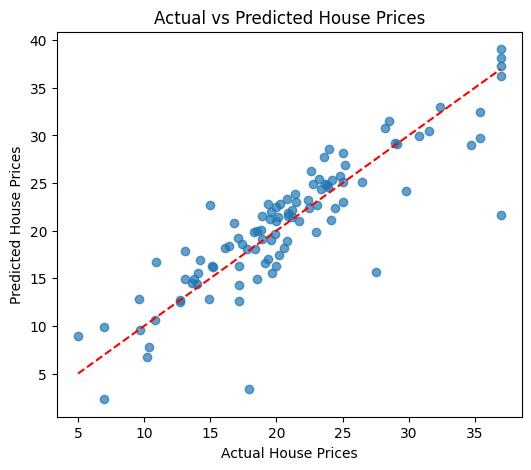

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

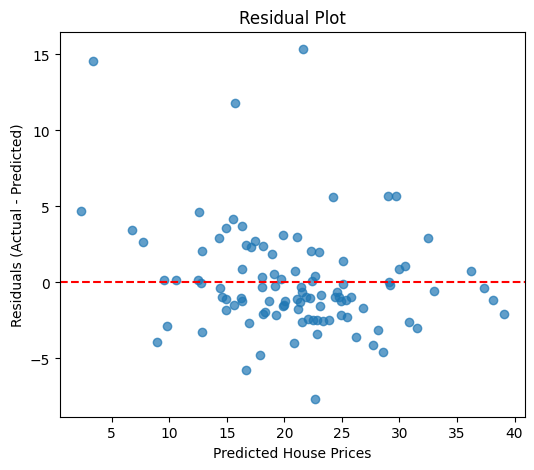

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

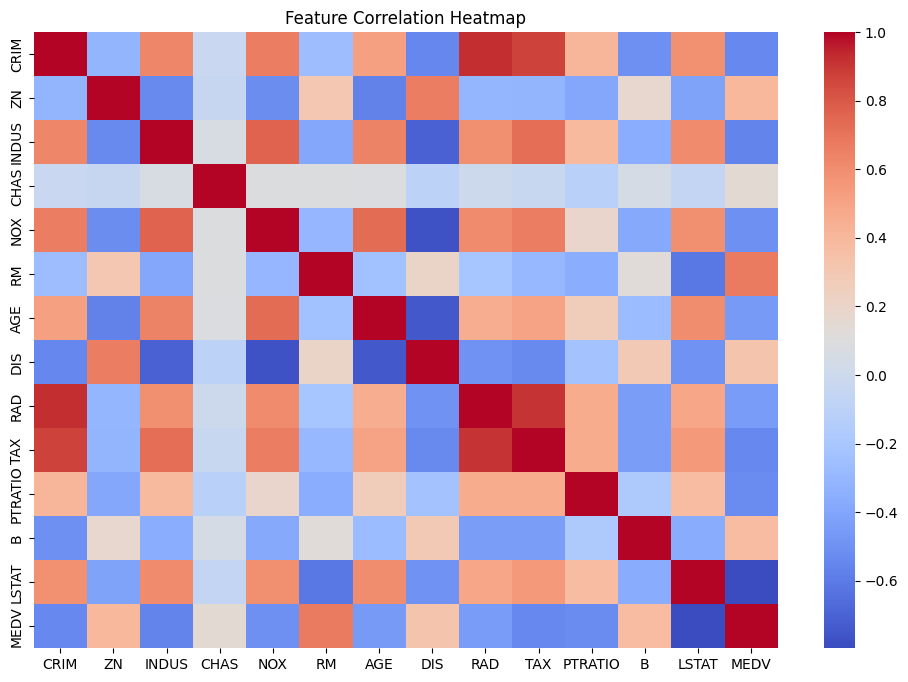

In [51]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df_feature_capped.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [56]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_s, y_train_s)

y_pred_scaled = lr_scaled.predict(X_test_s)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_scaled = np.sqrt(mean_squared_error(y_test_s, y_pred_scaled))
r2_scaled = r2_score(y_test_s, y_pred_scaled)


print("Model Performance After Feature Scaling:")
print(f"RMSE (Scaled): {rmse_scaled:.3f}")
print(f"R² Score (Scaled): {r2_scaled:.3f}")

Model Performance After Feature Scaling:
RMSE (Scaled): 3.484
R² Score (Scaled): 0.752
